## CODEX HCC — StarDist prediction visualization

This notebook is the CODEX HCC (s4769) counterpart of `Xenium_lung/Pred_statistic_visual_xenium_all.ipynb`.

Workflow:
1. Load clinical metadata from the Visium workbook (`Clinical_info`, `ALIGNED=='Y'` and `Annotation=='Y'`).
2. Plot **pooled StarDist ROC** for Level2 / Level12 / Level1 on those 36 regions.
3. Compare per-region **macro AUROC** across **Response**, **diagnosis**, and **treatment**.

Shared helpers live in `Hist2Pheno_pkg/uni_label_cv_helpers.py`; HCC-specific loaders stay in `s4769_plot.py`.


In [1]:
## Setup (CODEX HCC)
import matplotlib

matplotlib.rcParams["pdf.fonttype"] = 42
matplotlib.rcParams["ps.fonttype"] = 42

import sys
import warnings
import logging
from pathlib import Path

warnings.filterwarnings("ignore")
logging.getLogger("ome_zarr").setLevel(logging.ERROR)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Repo paths
REPO = Path("/home/lingyu/ssd2/Python/Hist2Pheno")
CODE_DIR = REPO / "code"
PKG_DIR = CODE_DIR / "Hist2Pheno_pkg"
HCC_CODE_DIR = CODE_DIR / "CODEX_hcc"

for _p in (PKG_DIR, HCC_CODE_DIR):
    if str(_p) not in sys.path:
        sys.path.insert(0, str(_p))

# Unified plotting selector (for shared plotting helpers).
PAN_ORGAN = "codex_hcc"

# HCC clinical + mapping sources (s4769)
DATA_ROOT = REPO / "data" / "CODEX" / "HCC" / "Michael_data_transfer" / "s4769"
HE_ROOT = DATA_ROOT / "HE"
CLINICAL_XLSX = HE_ROOT / "s4769_he_mapping_updated_Visium.xlsx"
CLINICAL_SHEET = "Clinical_info"

STARDIST_RESULT_ROOT = DATA_ROOT / "result_all_spatial" / "stardist"
OUT_DIR = DATA_ROOT / "result_all_spatial" / "clinical_viz"
OUT_DIR.mkdir(parents=True, exist_ok=True)

print("DATA_ROOT:", DATA_ROOT)
print("OUT_DIR  :", OUT_DIR)
print("Clinical workbook:", CLINICAL_XLSX.name, "| sheet:", CLINICAL_SHEET)


DATA_ROOT: /home/lingyu/ssd2/Python/Hist2Pheno/data/CODEX/HCC/Michael_data_transfer/s4769
OUT_DIR  : /home/lingyu/ssd2/Python/Hist2Pheno/data/CODEX/HCC/Michael_data_transfer/s4769/result_all_spatial/clinical_viz
Clinical workbook: s4769_he_mapping_updated_Visium.xlsx | sheet: Clinical_info


## Load clinical information

Single source: `s4769_he_mapping_updated_Visium.xlsx` sheet `Clinical_info`.
Keep aligned + annotated regions (36 samples used for HCC StarDist runs).


In [2]:
import importlib
import s4769_plot

importlib.reload(s4769_plot)
from s4769_plot import load_hcc_clinical_info

clinical = load_hcc_clinical_info(CLINICAL_XLSX, sheet_name=CLINICAL_SHEET)


Clinical sheet rows: 50
Retained rows      : 36


,matched_he,region_id,region_label,region_label,patient_id,diagnosis,Response,treatment,tissue_type,tissue_subtype,Visium,Annotation
0,awy-98938_aligned_0d535a74,FinalLiv-27_c001_v001_r001_reg001,70_2,70_2,85557,Pre,Responder,List A,Liver,Primary,N,Y
1,awy-98938_aligned_8ded610e,FinalLiv-27_c001_v001_r001_reg002,70_3,70_3,85557,Pre,Responder,List A,Liver,Primary,N,Y
2,awy-98938_aligned_a5afeef9,FinalLiv-27_c001_v001_r001_reg003,70_4,70_4,85557,Post,Responder,List A,Liver,Primary,N,Y
3,awy-98938_aligned_59f27598,FinalLiv-27_c001_v001_r001_reg004,70_5,70_5,85557,Post,Responder,List A,Liver,Primary,N,Y
4,nwn-95916_aligned_d1ec33a2,FinalLiv-27_c001_v001_r001_reg005,71_2,71_2,85558,Pre,Responder,List A,Liver,Primary,Y,Y
5,nwn-95916_aligned_b16cf712,FinalLiv-27_c001_v001_r001_reg006,71_3,71_3,85558,Pre,Responder,List A,Liver,Primary,Y,Y
6,nwn-95916_aligned_459f2ffd,FinalLiv-27_c001_v001_r001_reg007,71_4,71_4,85558,Post,Responder,List A,Liver,Primary,N,Y
7,nwn-95916_aligned_737dafc9,FinalLiv-27_c001_v001_r001_reg008,71_5,71_5,85558,Post,Responder,List A,Liver,Primary,N,Y
8,dpn-56105_aligned_b32cf147,FinalLiv-27_c001_v001_r001_reg009,72_2,72_2,85559,Pre,Non_Responder,List A,Liver,Primary,Y,Y
9,dpn-56105_aligned_d24763ad,FinalLiv-27_c001_v001_r001_reg010,72_3,72_3,85559,Pre,Non_Responder,List A,Liver,Primary,Y,Y



diagnosis


diagnosis
Pre     18
Post    18
Name: count, dtype: int64


Response


...

tissue_subtype
Primary       34
Metastatis     2
Name: count, dtype: int64


Visium


Visium
Y    20
N    16
Name: count, dtype: int64


Annotation


Annotation
Y    36
Name: count, dtype: int64

## Pooled StarDist ROC (annotated aligned regions)

Build a filtered root of **symlinks** to the 36 annotated regions, then plot pooled OvR ROC for `l2` / `l12` / `l1`.


Linked 36/36 StarDist sample dirs under /home/lingyu/ssd2/Python/Hist2Pheno/data/CODEX/HCC/Michael_data_transfer/s4769/result_all_spatial/clinical_viz/_tmp_selected_stardist

=== L2 | discovering validation_external_stardist_matched_AUROC.csv ===
  awy-98938_aligned_0d535a74: 32,967 cells, 12 local classes
  awy-98938_aligned_59f27598: 32,333 cells, 12 local classes
  awy-98938_aligned_8ded610e: 12,262 cells, 12 local classes
  awy-98938_aligned_a5afeef9: 42,174 cells, 12 local classes
  dpn-56105_aligned_85543451: 25,780 cells, 12 local classes
  dpn-56105_aligned_b32cf147: 15,636 cells, 12 local classes
  dpn-56105_aligned_d24763ad: 13,120 cells, 12 local classes
  fcu-91631_aligned_1e3c06f5: 34,185 cells, 12 local classes
  fcu-91631_aligned_2e321bd1: 8,045 cells, 12 local classes
  fcu-91631_aligned_4722207f: 25,892 cells, 12 local classes
  fcu-91631_aligned_7ffa2d5a: 17,129 cells, 12 local classes
  kqr-83230_aligned_3bba12d6: 40,788 cells, 12 local classes
  kqr-83230_aligned_5b

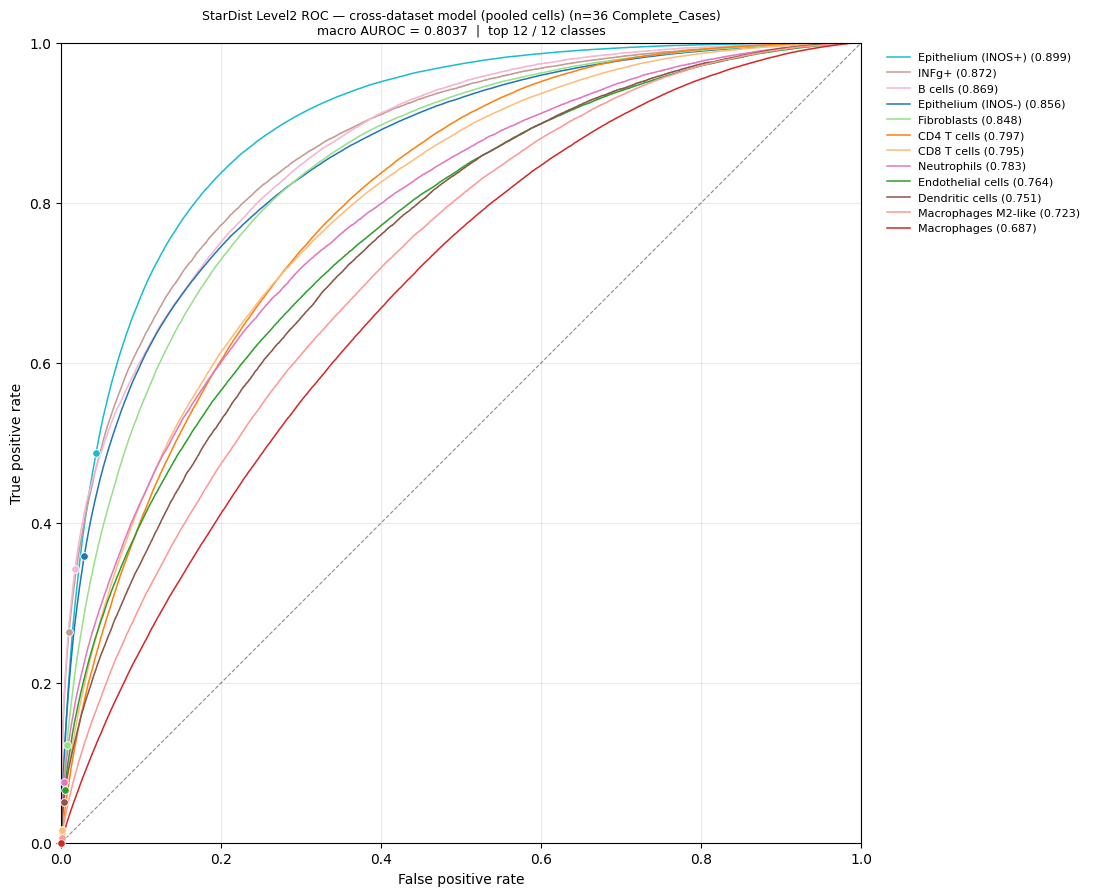

Pooled macro AUROC (L2): 0.8037

=== L12 | discovering validation_external_stardist_matched_AUROC_level12.csv ===
  awy-98938_aligned_0d535a74: 32,967 cells, 6 local classes
  awy-98938_aligned_59f27598: 32,333 cells, 6 local classes
  awy-98938_aligned_8ded610e: 12,262 cells, 6 local classes
  awy-98938_aligned_a5afeef9: 42,174 cells, 6 local classes
  dpn-56105_aligned_85543451: 25,780 cells, 6 local classes
  dpn-56105_aligned_b32cf147: 15,636 cells, 6 local classes
  dpn-56105_aligned_d24763ad: 13,120 cells, 6 local classes
  fcu-91631_aligned_1e3c06f5: 34,185 cells, 6 local classes
  fcu-91631_aligned_2e321bd1: 8,045 cells, 6 local classes
  fcu-91631_aligned_4722207f: 25,892 cells, 6 local classes
  fcu-91631_aligned_7ffa2d5a: 17,129 cells, 6 local classes
  kqr-83230_aligned_3bba12d6: 40,788 cells, 6 local classes
  kqr-83230_aligned_5b50bc37: 24,203 cells, 6 local classes
  kqr-83230_aligned_6f5021e3: 15,247 cells, 6 local classes
  kqr-83230_aligned_b24a3fb5: 32,882 cells, 6 l

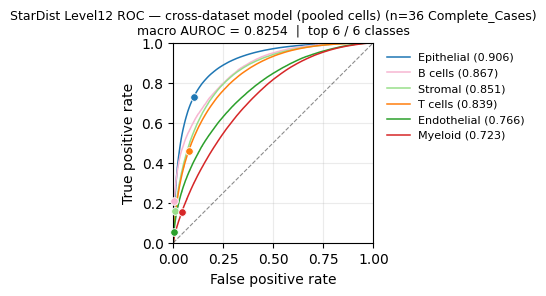

Pooled macro AUROC (L12): 0.8254

=== L1 | discovering validation_external_stardist_matched_AUROC_level1.csv ===
  awy-98938_aligned_0d535a74: 32,967 cells, 4 local classes
  awy-98938_aligned_59f27598: 32,333 cells, 4 local classes
  awy-98938_aligned_8ded610e: 12,262 cells, 4 local classes
  awy-98938_aligned_a5afeef9: 42,174 cells, 4 local classes
  dpn-56105_aligned_85543451: 25,780 cells, 4 local classes
  dpn-56105_aligned_b32cf147: 15,636 cells, 4 local classes
  dpn-56105_aligned_d24763ad: 13,120 cells, 4 local classes
  fcu-91631_aligned_1e3c06f5: 34,185 cells, 4 local classes
  fcu-91631_aligned_2e321bd1: 8,045 cells, 4 local classes
  fcu-91631_aligned_4722207f: 25,892 cells, 4 local classes
  fcu-91631_aligned_7ffa2d5a: 17,129 cells, 4 local classes
  kqr-83230_aligned_3bba12d6: 40,788 cells, 4 local classes
  kqr-83230_aligned_5b50bc37: 24,203 cells, 4 local classes
  kqr-83230_aligned_6f5021e3: 15,247 cells, 4 local classes
  kqr-83230_aligned_b24a3fb5: 32,882 cells, 4 lo

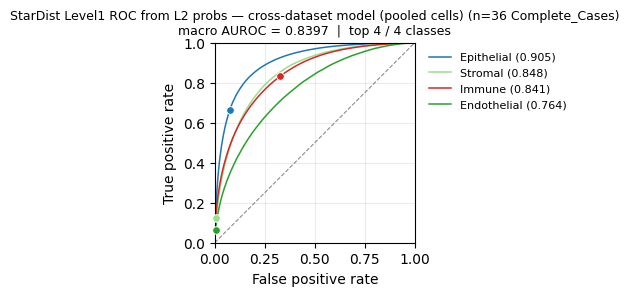

Pooled macro AUROC (L1): 0.8397


In [3]:
import importlib
import uni_label_cv_helpers as uni_nb
import s4769_plot

importlib.reload(uni_nb)
importlib.reload(s4769_plot)
from s4769_plot import HCC_STARDIST_MACRO_AUROC_TIERS
from uni_label_cv_helpers import plot_pooled_stardist_tier_rocs, symlink_stardist_sample_dirs

filtered_root = symlink_stardist_sample_dirs(
    STARDIST_RESULT_ROOT,
    clinical["matched_he"],
    OUT_DIR / "_tmp_selected_stardist",
)

pooled_roc = plot_pooled_stardist_tier_rocs(
    filtered_root,
    OUT_DIR,
    HCC_STARDIST_MACRO_AUROC_TIERS,
    layout="pooled_stardist",
    pan_organ=PAN_ORGAN,
    figsize={"l12": (2.0, 2.0), "l1": (2.0, 2.0)},
)


## StarDist macro AUROC vs clinical groups

Per-region macro AUROC compared across **Response**, **diagnosis**, and **treatment**.

- `method="rank"`: Mann–Whitney U (2 groups) or Kruskal–Wallis (3+)
- `method="parametric"`: Welch t-test (2 groups) or one-way ANOVA (3+)



=== L2 macro AUROC vs clinical groups (method=rank) ===


,clinical_variable,metric_col,method,test,p_value,statistic,n_groups,group_labels,group_median_q4,group_median_values,neg_log10_p
0,Response,macro_auc_l2,rank,Mann-Whitney U,0.009922,80.0,2,"[Responder, Non_Responder]","[0.7327122022745542, 0.7826772844032224]","[0.7327122022745542, 0.7826772844032224]",2.003413
1,diagnosis,macro_auc_l2,rank,Mann-Whitney U,0.178741,119.0,2,"[Pre, Post]","[0.7386266654939067, 0.7652489270652894]","[0.7386266654939067, 0.7652489270652894]",0.747775
2,treatment,macro_auc_l2,rank,Mann-Whitney U,0.757873,144.0,2,"[List A, List B]","[0.7505005103168887, 0.74853321346195]","[0.7505005103168887, 0.74853321346195]",0.120403


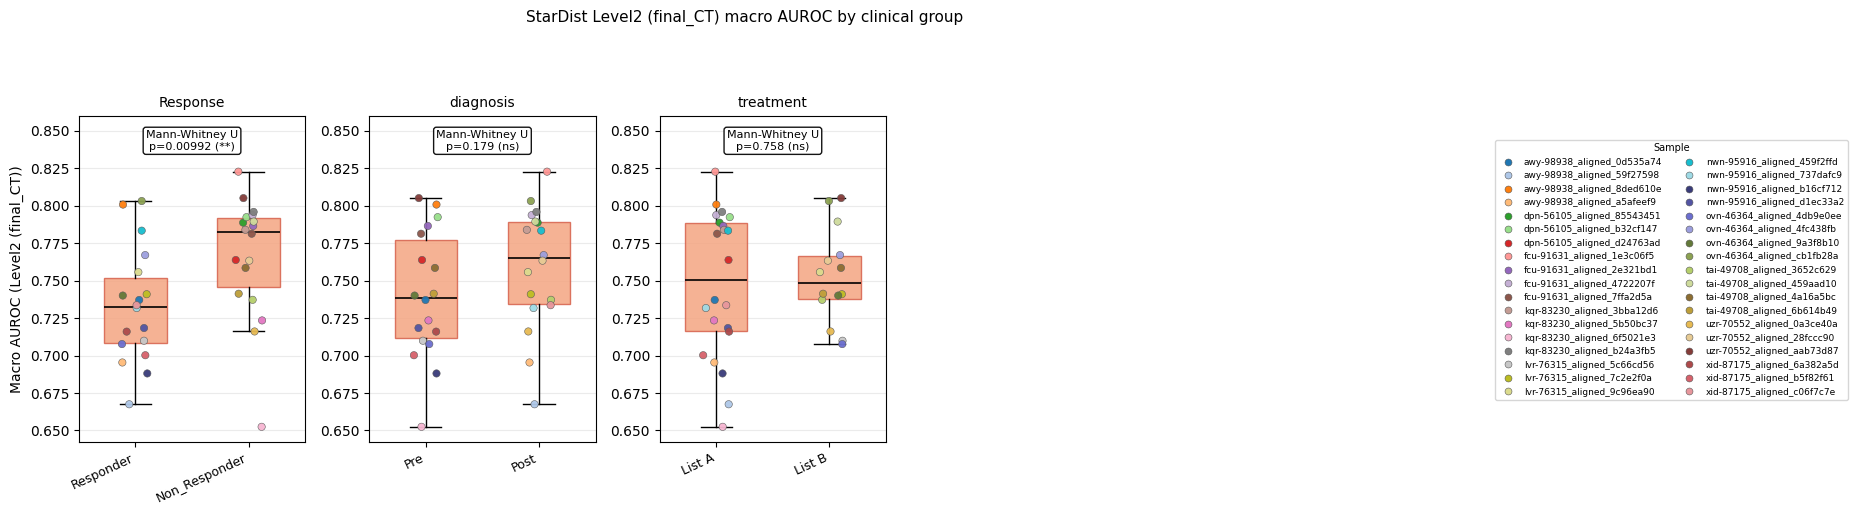


=== L12 macro AUROC vs clinical groups (method=rank) ===


,clinical_variable,metric_col,method,test,p_value,statistic,n_groups,group_labels,group_median_q4,group_median_values,neg_log10_p
0,Response,macro_auc_l12,rank,Mann-Whitney U,0.030216,93.0,2,"[Responder, Non_Responder]","[0.7604703926157987, 0.8087110829390274]","[0.7604703926157987, 0.8087110829390274]",1.519759
1,diagnosis,macro_auc_l12,rank,Mann-Whitney U,0.168735,118.0,2,"[Pre, Post]","[0.7851186455006991, 0.8040832283362584]","[0.7851186455006991, 0.8040832283362584]",0.772794
2,treatment,macro_auc_l12,rank,Mann-Whitney U,0.637980,139.0,2,"[List A, List B]","[0.7871781498098388, 0.7987674161707194]","[0.7871781498098388, 0.7987674161707194]",0.195193


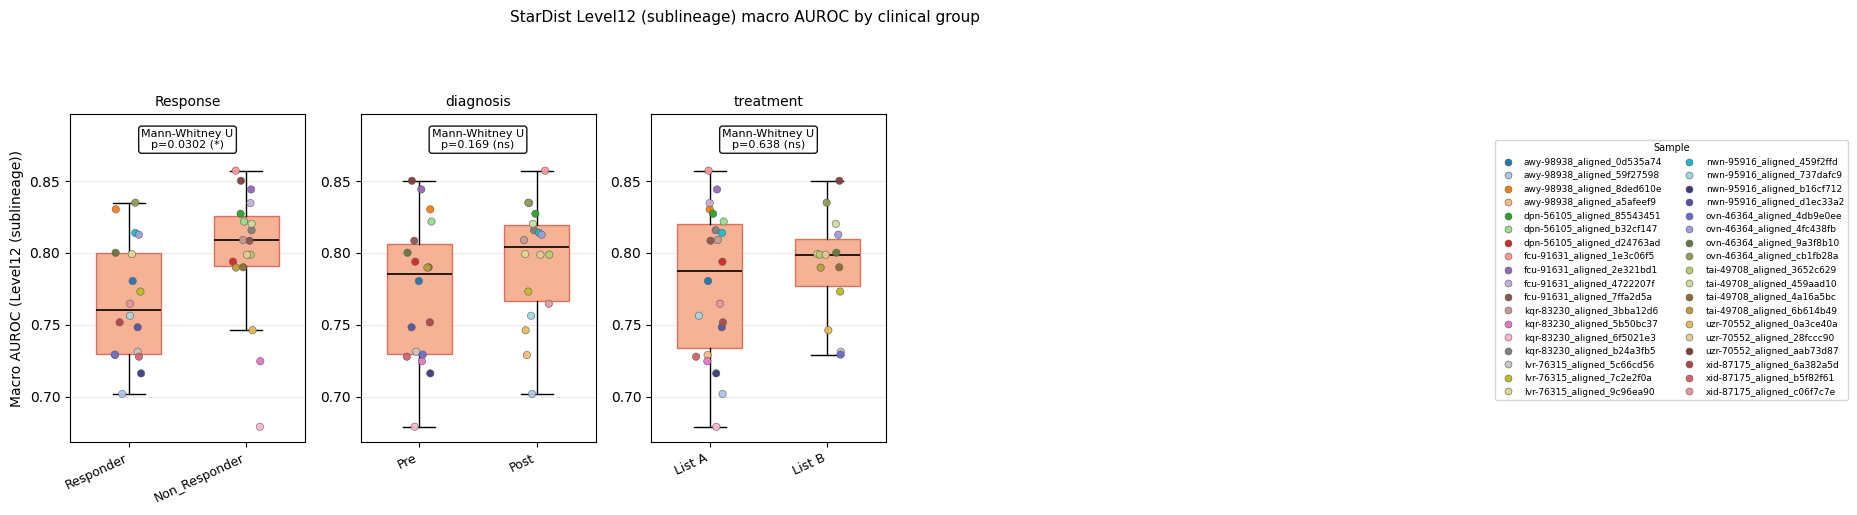


=== L1 macro AUROC vs clinical groups (method=rank) ===


,clinical_variable,metric_col,method,test,p_value,statistic,n_groups,group_labels,group_median_q4,group_median_values,neg_log10_p
0,Response,macro_auc_l1,rank,Mann-Whitney U,0.149993,116.0,2,"[Responder, Non_Responder]","[0.7889688900633383, 0.8223187077488613]","[0.7889688900633383, 0.8223187077488613]",0.823929
1,diagnosis,macro_auc_l1,rank,Mann-Whitney U,0.419791,136.0,2,"[Pre, Post]","[0.8043631512098028, 0.8181874047310469]","[0.8043631512098028, 0.8181874047310469]",0.376967
2,treatment,macro_auc_l1,rank,Mann-Whitney U,0.570120,136.0,2,"[List A, List B]","[0.8045329034396084, 0.8155177740749189]","[0.8045329034396084, 0.8155177740749189]",0.244034


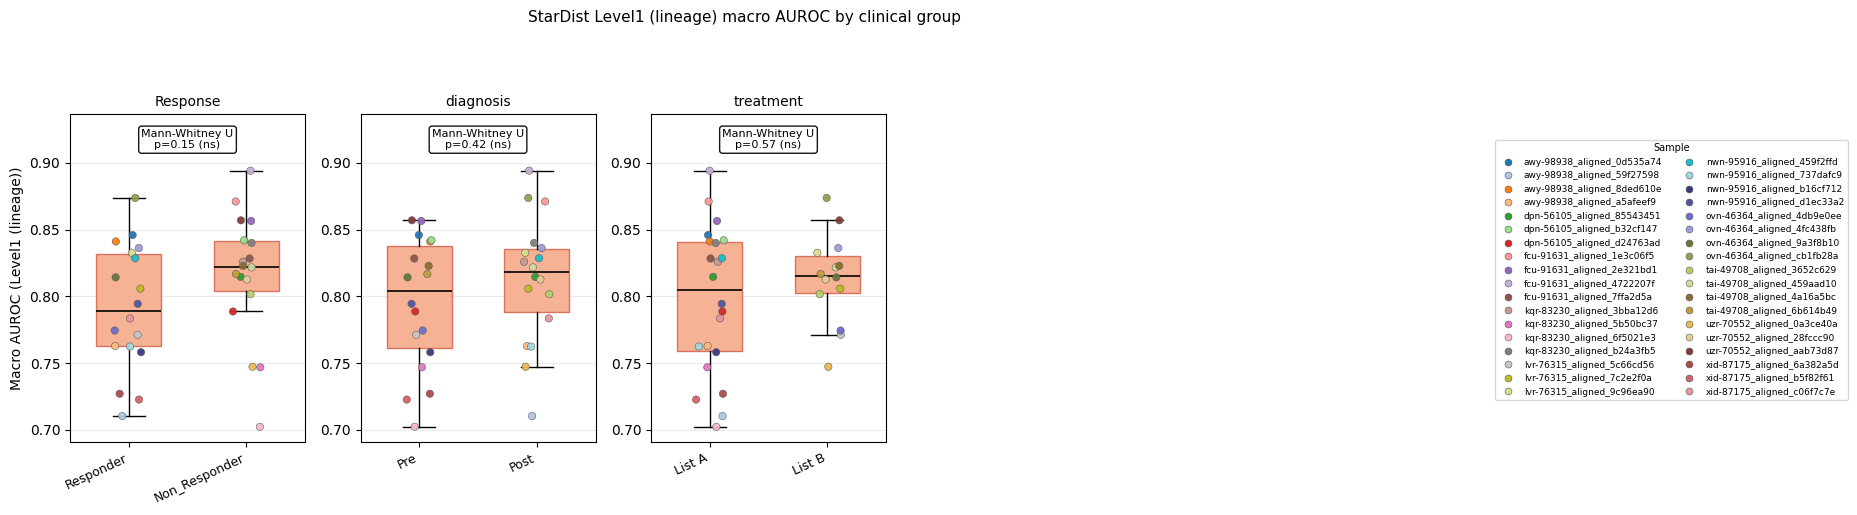

In [4]:
import importlib
import s4769_plot

importlib.reload(s4769_plot)
from s4769_plot import analyze_hcc_stardist_macro_auroc_by_clinical

stardist_auroc_clinical = analyze_hcc_stardist_macro_auroc_by_clinical(
    filtered_root,
    clinical,
    method="rank",
    # method="parametric",
    # save_dir=OUT_DIR / "stardist_auroc_clinical",
)
